# SHAP Analysis: Global, Local & Stability

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import matplotlib.pyplot as plt

os.makedirs('shap_output', exist_ok=True)
os.makedirs('shap_analysis', exist_ok=True)

## 1. Load & Setup

In [2]:
df = pd.read_csv('features_final.csv')
df['week_start'] = pd.to_datetime(df['week_start'])
df = df.sort_values(['week_start', 'product_id']).reset_index(drop=True)

pred_df = pd.read_csv('xgb_final_predictions.csv')
pred_df['week_start'] = pd.to_datetime(pred_df['week_start'])

TARGET    = 'sku_sold'
DROP_COLS = ['product_id', 'week_start', 'year', 'week', TARGET]
FEATURES  = [c for c in df.columns if c not in DROP_COLS]

XGB_PARAMS = dict(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    min_child_weight=5, random_state=42, verbosity=0,
)

FOLD_SPLITS = [
    ('2018-02-19', '2019-12-30', '2020-01-06', '2020-03-30'),
    ('2018-02-19', '2020-03-30', '2020-04-06', '2020-06-29'),
    ('2018-02-19', '2020-06-29', '2020-07-06', '2020-09-28'),
    ('2018-02-19', '2020-09-28', '2020-10-05', '2020-12-28'),
]

# Retrain final model on 2018–2020
train_final = df[df['week_start'] <= '2020-12-28']
test_final  = df[(df['week_start'] >= '2021-01-01') & (df['week_start'] <= '2021-12-31')]

final_model = xgb.XGBRegressor(**XGB_PARAMS)
final_model.fit(train_final[FEATURES], train_final[TARGET].values)

# Compute SHAP values for 2021 holdout
explainer   = shap.TreeExplainer(final_model)
shap_values = explainer(test_final[FEATURES])
test_reset  = test_final.reset_index(drop=True)

print(f'Features: {len(FEATURES)}')
print(f'SHAP values shape: {shap_values.values.shape}')

Features: 40
SHAP values shape: (3186, 40)


## 2. Global SHAP — Bar Plot

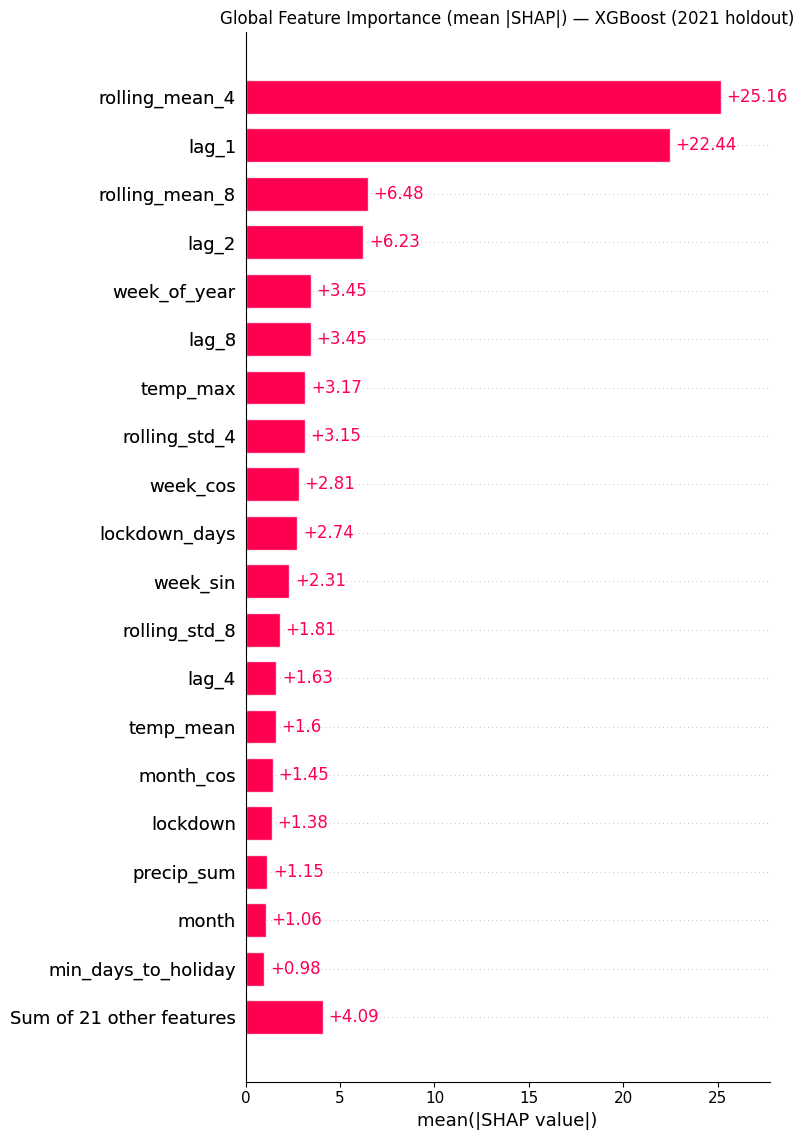

Saved: shap_output/global_bar.png


In [3]:
plt.figure()
shap.plots.bar(shap_values, max_display=20, show=False)
plt.title('Global Feature Importance (mean |SHAP|) — XGBoost (2021 holdout)')
plt.tight_layout()
plt.savefig('shap_output/global_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: shap_output/global_bar.png')

## 3. Local SHAP — Waterfall (3 sample products)

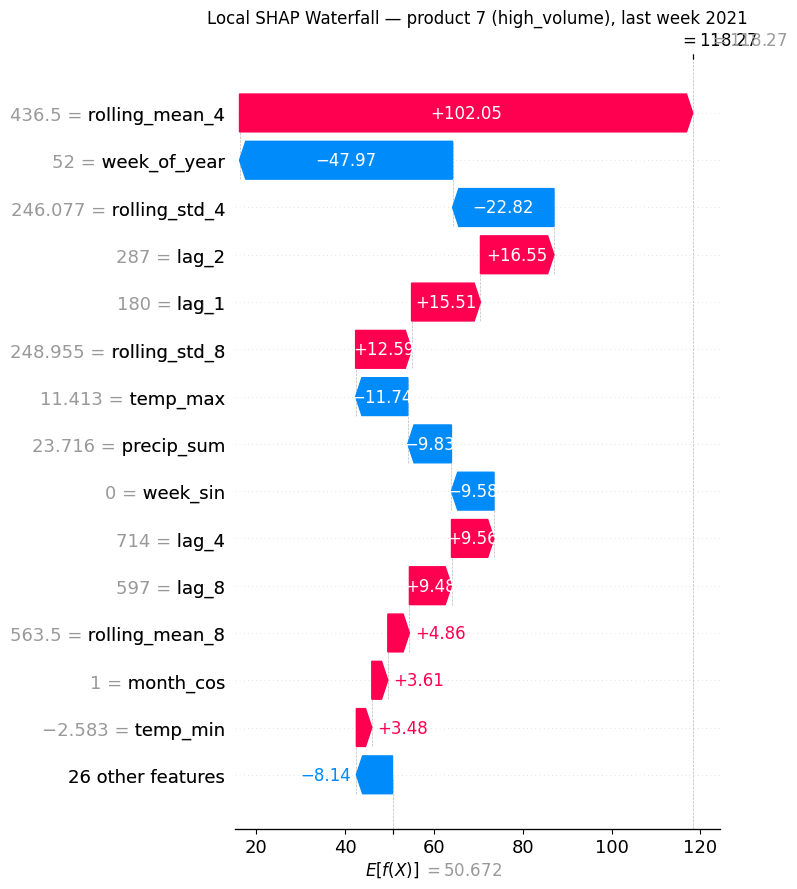

Saved: shap_output/local_waterfall_high_volume_product7.png


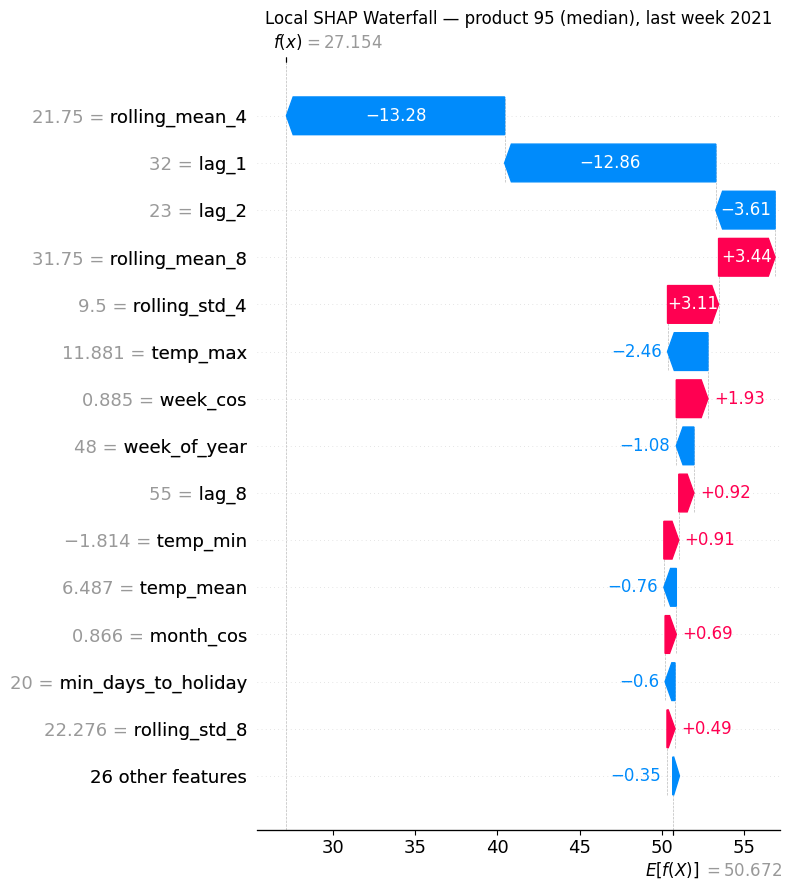

Saved: shap_output/local_waterfall_median_product95.png


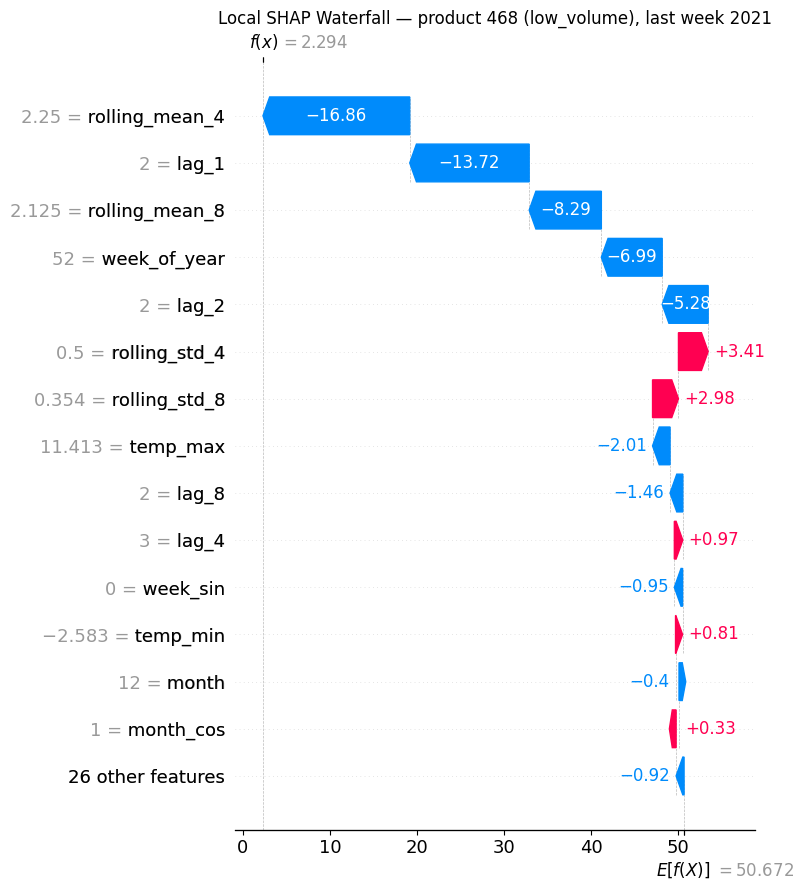

Saved: shap_output/local_waterfall_low_volume_product468.png


In [4]:
product_means = test_final.groupby('product_id')[TARGET].mean()
sorted_means  = product_means.sort_values()

sample_products = {
    'high_volume': sorted_means.index[-1],
    'median':      sorted_means.index[len(sorted_means) // 2],
    'low_volume':  sorted_means.index[0],
}

for label, pid in sample_products.items():
    pid_rows = test_reset[test_reset['product_id'] == pid]
    if pid_rows.empty:
        continue
    row_idx = pid_rows.index[-1]

    plt.figure()
    shap.plots.waterfall(shap_values[row_idx], max_display=15, show=False)
    plt.title(f'Local SHAP Waterfall — product {pid} ({label}), last week 2021')
    plt.tight_layout()
    fname = f'shap_output/local_waterfall_{label}_product{pid}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

## 4. Stability — Compute SHAP per Fold

In [5]:
fold_shap_means = []
fold_shap_ranks = []
fold_labels     = []

all_splits  = FOLD_SPLITS + [('2018-02-19', '2020-12-28', '2021-01-01', '2021-12-31')]
label_names = ['Fold 1', 'Fold 2', 'Fold 3', 'Fold 4', 'Final 2021']

for label, (tr_start, tr_end, te_start, te_end) in zip(label_names, all_splits):
    train = df[(df['week_start'] >= tr_start) & (df['week_start'] <= tr_end)]
    test  = df[(df['week_start'] >= te_start) & (df['week_start'] <= te_end)]

    model = xgb.XGBRegressor(**XGB_PARAMS)
    model.fit(train[FEATURES], train[TARGET].values)

    sv       = shap.TreeExplainer(model)(test[FEATURES])
    mean_abs = np.abs(sv.values).mean(axis=0)

    fold_shap_means.append(mean_abs)
    fold_shap_ranks.append(
        pd.Series(mean_abs, index=FEATURES).rank(ascending=False).astype(int)
    )
    fold_labels.append(label)
    print(f'{label} done — test rows: {len(test)}')

means_df = pd.DataFrame(fold_shap_means, columns=FEATURES, index=fold_labels)
ranks_df = pd.DataFrame(fold_shap_ranks, index=fold_labels)

Fold 1 done — test rows: 931
Fold 2 done — test rows: 878
Fold 3 done — test rows: 748
Fold 4 done — test rows: 713
Final 2021 done — test rows: 3186


## 5. Stability — Rank Heatmap

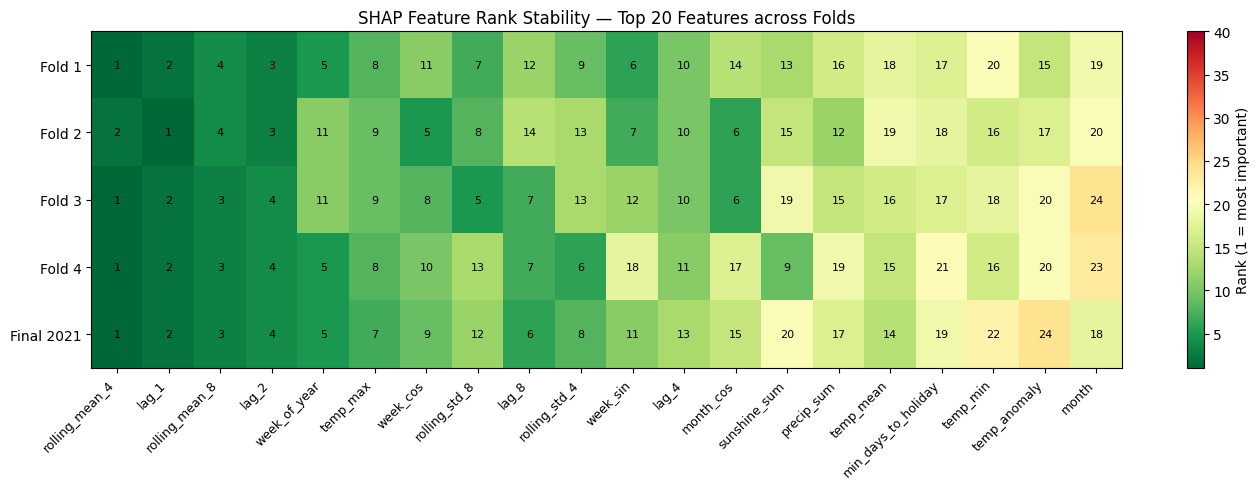

Saved: shap_analysis/stability_rank_heatmap.png


In [6]:
mean_rank    = ranks_df.mean().sort_values()
top_features = mean_rank.head(20).index.tolist()
plot_ranks   = ranks_df[top_features]

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(plot_ranks.values, aspect='auto', cmap='RdYlGn_r', vmin=1, vmax=len(FEATURES))
plt.colorbar(im, ax=ax, label='Rank (1 = most important)')

ax.set_xticks(range(len(top_features)))
ax.set_xticklabels(top_features, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(fold_labels)))
ax.set_yticklabels(fold_labels)

for i in range(len(fold_labels)):
    for j in range(len(top_features)):
        ax.text(j, i, str(plot_ranks.values[i, j]),
                ha='center', va='center', fontsize=8, color='black')

ax.set_title('SHAP Feature Rank Stability — Top 20 Features across Folds')
plt.tight_layout()
plt.savefig('shap_analysis/stability_rank_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: shap_analysis/stability_rank_heatmap.png')

## 6. Stability — Magnitude Trend

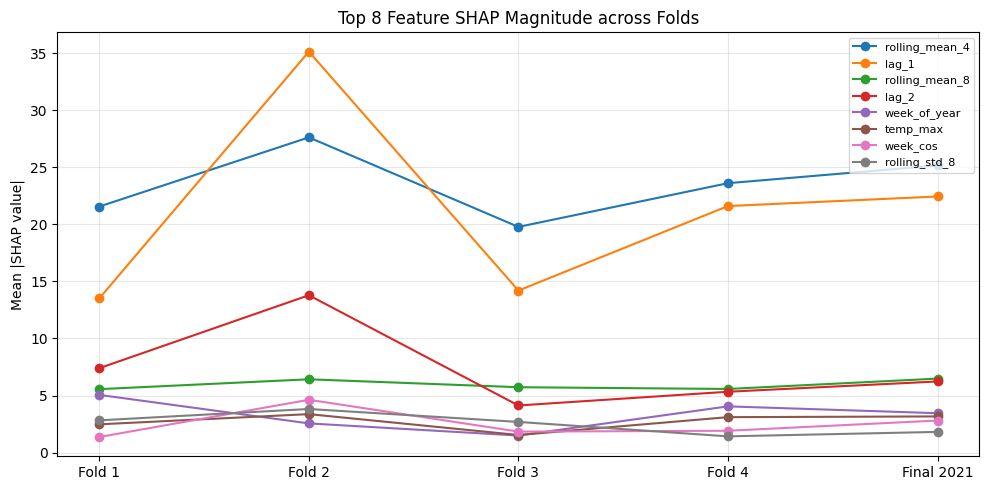

Saved: shap_analysis/stability_magnitude_trend.png


In [7]:
top8 = mean_rank.head(8).index.tolist()

fig, ax = plt.subplots(figsize=(10, 5))
for feat in top8:
    ax.plot(fold_labels, means_df[feat].values, marker='o', label=feat)

ax.set_ylabel('Mean |SHAP value|')
ax.set_title('Top 8 Feature SHAP Magnitude across Folds')
ax.legend(loc='upper right', fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('shap_analysis/stability_magnitude_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: shap_analysis/stability_magnitude_trend.png')

## 7. Stability — Rank Summary Table

In [8]:
stability_df = pd.DataFrame({
    'mean_rank': ranks_df.mean(),
    'std_rank':  ranks_df.std(),
    'min_rank':  ranks_df.min(),
    'max_rank':  ranks_df.max(),
}).sort_values('mean_rank').round(2)

print('Feature rank stability (lower std = more stable):')
print(stability_df.head(20).to_string())

Feature rank stability (lower std = more stable):
                     mean_rank  std_rank  min_rank  max_rank
rolling_mean_4             1.2      0.45         1         2
lag_1                      1.8      0.45         1         2
rolling_mean_8             3.4      0.55         3         4
lag_2                      3.6      0.55         3         4
week_of_year               7.4      3.29         5        11
temp_max                   8.2      0.84         7         9
week_cos                   8.6      2.30         5        11
rolling_std_8              9.0      3.39         5        13
lag_8                      9.2      3.56         6        14
rolling_std_4              9.8      3.11         6        13
week_sin                  10.8      4.76         6        18
lag_4                     10.8      1.30        10        13
month_cos                 11.6      5.22         6        17
sunshine_sum              15.2      4.49         9        20
precip_sum                15.8     

## 8. Stratified — Product WAPE Tiers

In [9]:
product_wape = (
    pred_df.groupby('product_id')
    .apply(lambda g: pd.Series({
        'wape': (g['sku_sold'] - g['xgb_pred']).abs().sum() /
                (g['sku_sold'].abs().sum() + 1e-8) * 100,
        'actual_mean': g['sku_sold'].mean(),
        'n_weeks': len(g)
    }))
    .reset_index()
)

product_wape['tier'] = pd.cut(
    product_wape['wape'],
    bins=[0, 30, 60, float('inf')],
    labels=['Good (<30%)', 'Medium (30–60%)', 'Poor (>60%)']
)

print(product_wape['tier'].value_counts())
print()
print(product_wape.groupby('tier')['wape'].describe().round(1))

tier
Poor (>60%)        43
Medium (30–60%)    37
Good (<30%)         0
Name: count, dtype: int64

                 count  mean   std   min   25%   50%   75%    max
tier                                                             
Good (<30%)        0.0   NaN   NaN   NaN   NaN   NaN   NaN    NaN
Medium (30–60%)   37.0  49.8   6.7  34.4  44.3  51.8  54.5   59.3
Poor (>60%)       43.0  78.7  17.4  60.5  64.5  74.2  86.8  130.8


## 9. Stratified — SHAP per Tier

In [10]:
# Build SHAP df from already-computed shap_values (2021 holdout)
shap_df = pd.DataFrame(shap_values.values, columns=FEATURES)
shap_df['product_id'] = test_reset['product_id'].values
shap_df = shap_df.merge(product_wape[['product_id', 'tier']], on='product_id', how='left')

tier_shap = (
    shap_df.groupby('tier')[FEATURES]
    .apply(lambda g: g.abs().mean())
)

top10 = means_df.mean().abs().sort_values(ascending=False).head(10).index
print('Mean |SHAP| by tier (top 10 features):')
print(tier_shap[top10].round(3).to_string())

Mean |SHAP| by tier (top 10 features):
                 rolling_mean_4   lag_1  lag_2  rolling_mean_8  week_of_year  temp_max  rolling_std_8  week_cos  lag_8  week_sin
tier                                                                                                                            
Good (<30%)                 NaN     NaN    NaN             NaN           NaN       NaN            NaN       NaN    NaN       NaN
Medium (30–60%)          31.848  29.430  7.933           7.392         4.096     3.849          2.414     3.577  4.188     3.067
Poor (>60%)              17.273  14.195  4.225           5.412         2.692     2.365          1.102     1.903  2.572     1.416


## 10. Stratified — Bar Chart

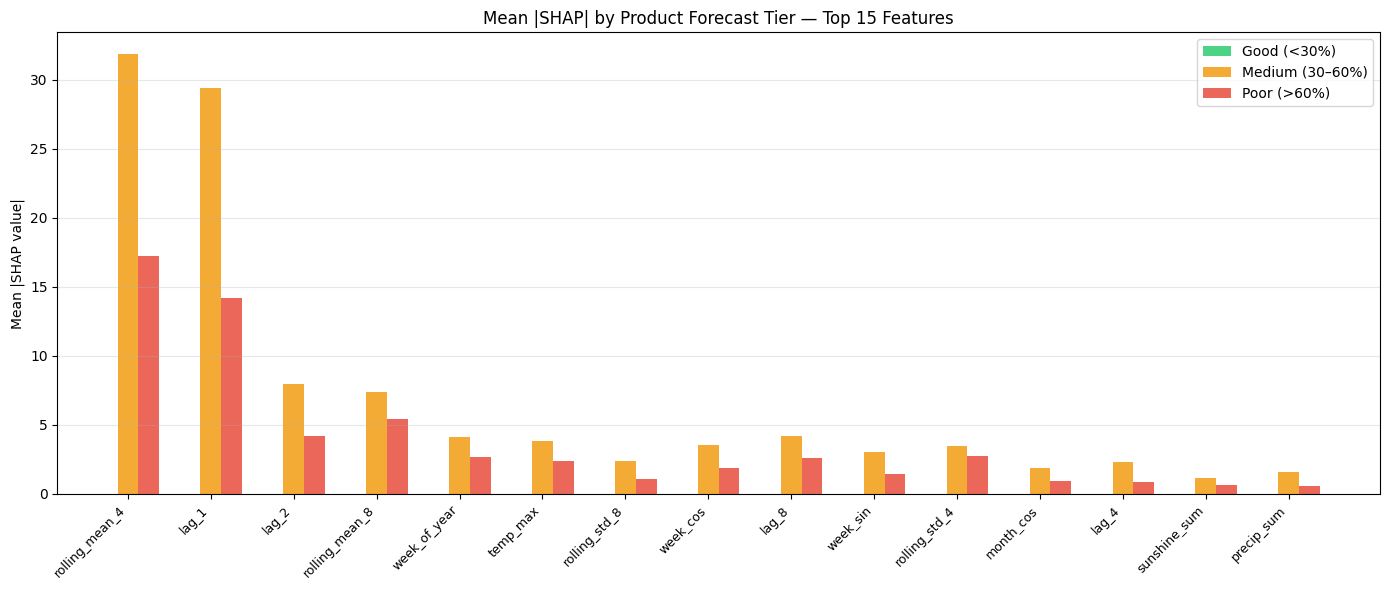

Saved: shap_analysis/stratified_shap_bar.png


In [11]:
top15  = means_df.mean().abs().sort_values(ascending=False).head(15).index.tolist()
tiers  = tier_shap.index.tolist()
colors = ['#2ecc71', '#f39c12', '#e74c3c']
x      = np.arange(len(top15))
width  = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
for i, (tier, color) in enumerate(zip(tiers, colors)):
    ax.bar(x + i * width, tier_shap.loc[tier, top15].values,
           width=width, label=tier, color=color, alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(top15, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Mean |SHAP value|')
ax.set_title('Mean |SHAP| by Product Forecast Tier — Top 15 Features')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('shap_analysis/stratified_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: shap_analysis/stratified_shap_bar.png')

## 11. Stratified — Normalised Share (Stacked Bar)

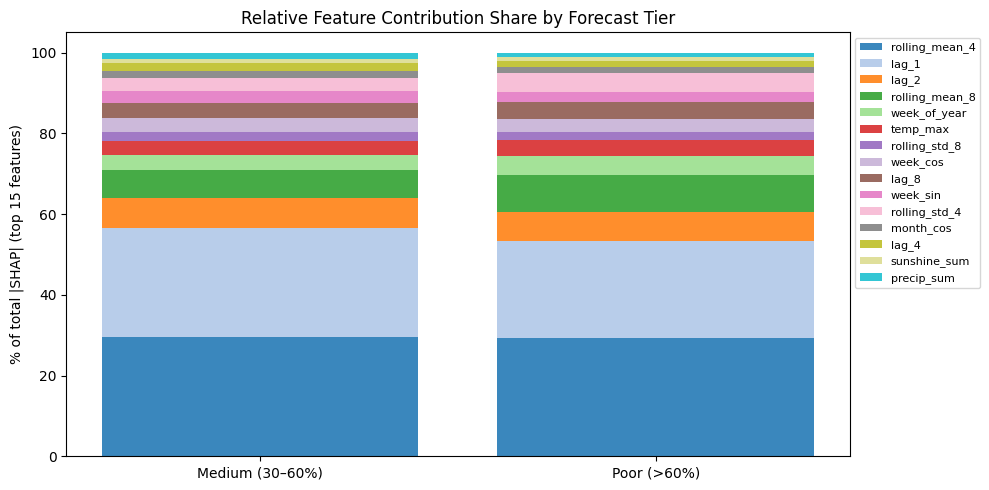

Saved: shap_analysis/stratified_shap_share.png


In [12]:
tier_norm = tier_shap[top15].div(tier_shap[top15].sum(axis=1), axis=0) * 100
cmap      = plt.get_cmap('tab20')
bottom    = np.zeros(len(tiers))

fig, ax = plt.subplots(figsize=(10, 5))
for j, feat in enumerate(top15):
    vals = tier_norm[feat].values
    ax.bar(tiers, vals, bottom=bottom, label=feat,
           color=cmap(j / len(top15)), alpha=0.88)
    bottom += vals

ax.set_ylabel('% of total |SHAP| (top 15 features)')
ax.set_title('Relative Feature Contribution Share by Forecast Tier')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=8)
plt.tight_layout()
plt.savefig('shap_analysis/stratified_shap_share.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: shap_analysis/stratified_shap_share.png')

## 12. Export

In [13]:
# Raw SHAP values (2021 holdout)
shap_out = pd.DataFrame(shap_values.values, columns=FEATURES)
shap_out['product_id'] = test_reset['product_id'].values
shap_out['week_start'] = test_reset['week_start'].values
shap_out.to_csv('shap_output/shap_values_2021.csv', index=False)

# Stability summary
stability_df.to_csv('shap_analysis/stability_summary.csv')

# Product tier assignments
product_wape.to_csv('shap_analysis/product_tiers.csv', index=False)

# Mean |SHAP| per tier per feature
tier_shap.T.to_csv('shap_analysis/tier_shap_means.csv')

print('Done. Files saved:')
print('  shap_output/global_bar.png')
print('  shap_output/local_waterfall_*.png  (x3)')
print('  shap_output/shap_values_2021.csv')
print('  shap_analysis/stability_rank_heatmap.png')
print('  shap_analysis/stability_magnitude_trend.png')
print('  shap_analysis/stability_summary.csv')
print('  shap_analysis/stratified_shap_bar.png')
print('  shap_analysis/stratified_shap_share.png')
print('  shap_analysis/product_tiers.csv')
print('  shap_analysis/tier_shap_means.csv')

Done. Files saved:
  shap_output/global_bar.png
  shap_output/local_waterfall_*.png  (x3)
  shap_output/shap_values_2021.csv
  shap_analysis/stability_rank_heatmap.png
  shap_analysis/stability_magnitude_trend.png
  shap_analysis/stability_summary.csv
  shap_analysis/stratified_shap_bar.png
  shap_analysis/stratified_shap_share.png
  shap_analysis/product_tiers.csv
  shap_analysis/tier_shap_means.csv
